<a href="https://colab.research.google.com/github/danangcorp/Analisis-Data-Customer-Churn/blob/main/Analisis_Customer_Churn_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analisis Data Customer Insights & Churn E-Commerce
Notebook/Laporan ini bertujuan untuk menganalisis data pelanggan e-commerce guna memahami perilaku belanja dan mengidentifikasi karakteristik pelanggan yang berpotensi melakukan churn (berhenti berlangganan/berbelanja). Analisis ini akan membantu manajemen dalam merumuskan strategi retensi pelanggan yang tepat dan berbasis data.

# Tahapan Analisis Data E-Commerce
Berikut adalah bagian awal dari tahapan analisis data pelanggan e-commerce:
##1. Pendahuluan

Industri e-commerce tumbuh sangat pesat, memicu persaingan yang ketat dalam mempertahankan pelanggan. Mengakuisisi pelanggan baru membutuhkan biaya yang jauh lebih besar daripada mempertahankan pelanggan yang sudah ada. Oleh karena itu, kemampuan untuk memprediksi dan mencegah pelanggan melakukan churn (pindah ke kompetitor) menjadi kunci keberlanjutan bisnis.

Perusahaan e-commerce ini merekam data profil, transaksi, dan status keaktifan pelanggan. Namun, data mentah tersebut belum diolah secara optimal untuk memberikan wawasan strategis. Melalui proyek ini, data akan dibersihkan, dieksplorasi, dan dianalisis untuk menemukan pola tersembunyi di balik keputusan pelanggan untuk bertahan atau pergi.

##2. Tujuan Proyek
Tujuan utama dari proyek analisis ini adalah mengidentifikasi faktor-faktor pemicu churn pelanggan dan menghasilkan rekomendasi aksi nyata (actionable insights) untuk meningkatkan kesetiaan pelanggan (customer retention).

##3. Rumusan Masalah / Pertanyaan Bisnis Utama (Menggunakan Metode SMART)
Untuk mencapai tujuan tersebut, analisis ini difokuskan untuk menjawab 4 pertanyaan bisnis utama yang dirumuskan secara SMART (Specific, Measurable, Actionable, Relevant, Time-bound):

BQ-1 (Tren Finansial & Churn): Apakah terdapat perbedaan yang signifikan pada rata-rata Total Spend (total pengeluaran) antara kelompok pelanggan yang Churn dan yang bertahan (Retention) selama periode pencatatan dataset ini?

BQ-2 (Karakteristik Demografi): Kelompok demografi pelanggan berdasarkan Age (usia) dan Gender (jenis kelamin) manakah yang memiliki persentase tingkat churn tertinggi dalam data saat ini?

BQ-3 (Loyalitas & Perilaku): Bagaimana pengaruh Tenure (lama berlangganan) dan Purchase Frequency (frekuensi pembelian) terhadap keputusan pelanggan untuk melakukan churn?

BQ-4 (Kepuasan Pelanggan): Berapa batasan skor Customer Satisfaction Rating minimum yang menunjukkan kecenderungan kuat seorang pelanggan akan melakukan churn dalam waktu dekat?

#1. Mengumpulkan Data (J.62DMI00.004.1)

##1.1 Import Library
Import NumPy
Import Pandas
Import Matplotlib
Import Seaborn

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##1.2 Memuat Dataset
Membaca file dataset
Menyimpan dataset ke dalam DataFrame

In [46]:
churn = pd.read_csv('/content/dirty_e_commerce_customer_insights.csv')
churn.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,ORD5000,CUST1000,39.0,PROD200,Canada,1/7/2021,2/21/2023,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female
1,ORD5001,CUST1001,61.0,PROD201,USA,10/19/2020,12/8/2021,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female
2,ORD5002,CUST1002,26.0,PROD202,Pakistan,6/10/2023,9/4/2023,3,cancelled,3/12/2025,604.14,2,44,Electronics,Hoodie,Clothing,Female
3,ORD5003,CUST1003,54.0,PROD203,India,7/30/2023,2/20/2024,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male
4,ORD5004,CUST1004,50.0,PROD204,India,12/9/2020,9/14/2024,0,active,8/8/2024,62.66,7,35,Sports,Smartwatch,Electronics,Male


##1.3 Memahami Dataset
Meninjau atribut yang tersedia
Mengidentifikasi jenis data pada setiap atribut

In [47]:
# Menampilkan seluruh nama kolom

print(churn.columns)

Index(['order_id', 'customer_id', 'age', 'product_id', 'country',
       'signup_date', 'last_purchase_date', 'cancellations_count',
       'subscription_status', 'order_date', 'unit_price', 'quantity',
       'purchase_frequency', 'preferred_category', 'product_name', 'category',
       'gender'],
      dtype='object')


#2. Menelaah Data (J.62DMI00.005.1)

##2.1 Menampilkan Sampel Data
Menampilkan beberapa baris pertama dataset
Menampilkan beberapa baris terakhir dataset

In [48]:
churn.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,ORD5000,CUST1000,39.0,PROD200,Canada,1/7/2021,2/21/2023,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female
1,ORD5001,CUST1001,61.0,PROD201,USA,10/19/2020,12/8/2021,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female
2,ORD5002,CUST1002,26.0,PROD202,Pakistan,6/10/2023,9/4/2023,3,cancelled,3/12/2025,604.14,2,44,Electronics,Hoodie,Clothing,Female
3,ORD5003,CUST1003,54.0,PROD203,India,7/30/2023,2/20/2024,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male
4,ORD5004,CUST1004,50.0,PROD204,India,12/9/2020,9/14/2024,0,active,8/8/2024,62.66,7,35,Sports,Smartwatch,Electronics,Male


In [49]:
churn.tail()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
2060,ORD6473,CUST2473,67.0,PROD1673,USA,12/10/2021,2/18/2025,1,cancelled,10/19/2023,86.11,5,23,Home,Nail Polish,Beauty,Other
2061,ORD5678,CUST1678,52.0,PROD878,Canada,6/2/2023,5/18/2024,2,paused,1/4/2025,244.14,6,10,Home,Refrigerator,Home,Female
2062,ORD6621,CUST2621,57.0,PROD1821,USA,8/19/2023,1/6/2025,2,paused,5/31/2024,502.39,2,34,Clothing,Laptop,Electronics,Male
2063,ORD6089,CUST2089,29.0,PROD1289,Canada,10/1/2020,9/6/2021,0,active,9/4/2021,61.45,9,42,Beauty,Face Wash,Beauty,Female
2064,ORD6987,CUST2987,65.0,PROD2187,Canada,12/5/2020,4/21/2024,3,active,1/24/2021,354.59,4,47,Electronics,Perfume,Beauty,Male


##2.2 Memeriksa Dimensi Dataset
Jumlah baris
Jumlah kolom

In [50]:
churn.shape

(2065, 17)

#2.3 Memeriksa Nama Kolom dan Tipe Data
Identifikasi atribut numerik
Identifikasi atribut kategorikal
Identifikasi atribut tanggal/waktu

In [51]:
churn.columns

Index(['order_id', 'customer_id', 'age', 'product_id', 'country',
       'signup_date', 'last_purchase_date', 'cancellations_count',
       'subscription_status', 'order_date', 'unit_price', 'quantity',
       'purchase_frequency', 'preferred_category', 'product_name', 'category',
       'gender'],
      dtype='object')

In [52]:
churn.dtypes

,0
order_id,object
customer_id,object
age,float64
product_id,object
country,object
signup_date,object
last_purchase_date,object
cancellations_count,int64
subscription_status,object
order_date,object


##2.4 Menampilkan Informasi Dataset
Struktur dataset
Statistik deskriptif

In [53]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2065 entries, 0 to 2064
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             2065 non-null   object 
 1   customer_id          2065 non-null   object 
 2   age                  2019 non-null   float64
 3   product_id           2065 non-null   object 
 4   country              1969 non-null   object 
 5   signup_date          2065 non-null   object 
 6   last_purchase_date   2065 non-null   object 
 7   cancellations_count  2065 non-null   int64  
 8   subscription_status  1976 non-null   object 
 9   order_date           2065 non-null   object 
 10  unit_price           2065 non-null   object 
 11  quantity             2065 non-null   int64  
 12  purchase_frequency   2065 non-null   int64  
 13  preferred_category   2065 non-null   object 
 14  product_name         2065 non-null   object 
 15  category             2065 non-null   o

In [54]:
churn.describe(include='all')

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
count,2065,2065,2019.000000,2065,1969,2065,2065,2065.000000,1976,2065,2065,2065.000000,2065.000000,2065,2065,2065,1998
unique,2000,2000,NaN,2000,7,926,1078,NaN,4,1099,1931,NaN,NaN,5,40,5,3
top,ORD6078,CUST2078,NaN,PROD1278,Germany,5/20/2023,11/30/2023,NaN,active,UNKNOWN,ERROR,NaN,NaN,Clothing,Sneakers,Clothing,Female
freq,2,2,NaN,2,351,9,8,NaN,1157,18,31,NaN,NaN,431,75,440,1026
mean,NaN,NaN,44.469044,NaN,NaN,NaN,NaN,2.443584,NaN,NaN,NaN,63.006780,25.169976,NaN,NaN,NaN,NaN
std,NaN,NaN,21.367412,NaN,NaN,NaN,NaN,1.701811,NaN,NaN,NaN,759.827591,14.167659,NaN,NaN,NaN,NaN
min,NaN,NaN,-99.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,3.000000,13.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,45.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,5.000000,25.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,7.000000,37.000000,NaN,NaN,NaN,NaN


In [55]:
churn.describe()

,age,cancellations_count,quantity,purchase_frequency
count,2019.000000,2065.000000,2065.000000,2065.000000
mean,44.469044,2.443584,63.006780,25.169976
std,21.367412,1.701811,759.827591,14.167659
min,-99.000000,0.000000,1.000000,1.000000
25%,31.000000,1.000000,3.000000,13.000000
50%,45.000000,2.000000,5.000000,25.000000
75%,57.000000,4.000000,7.000000,37.000000
max,250.000000,5.000000,9999.000000,49.000000


##2.5 Analisis Nilai Unik
Jumlah nilai unik pada atribut kategorikal

In [56]:
churn.nunique()

,0
order_id,2000
customer_id,2000
age,54
product_id,2000
country,7
signup_date,926
last_purchase_date,1078
cancellations_count,6
subscription_status,4
order_date,1099


In [57]:
churn['gender'].unique()

array(['Female', 'Male', 'Other', nan], dtype=object)

##2.6 Analisis Missing Value
Jumlah data kosong pada setiap kolom
Persentase data kosong

In [58]:
churn.isna().sum()

,0
order_id,0
customer_id,0
age,46
product_id,0
country,96
signup_date,0
last_purchase_date,0
cancellations_count,0
subscription_status,89
order_date,0


In [59]:
persentase_missing = (churn.isnull().sum() / len(churn)) * 100

print(round(persentase_missing,2))

order_id               0.00
customer_id            0.00
age                    2.23
product_id             0.00
country                4.65
signup_date            0.00
last_purchase_date     0.00
cancellations_count    0.00
subscription_status    4.31
order_date             0.00
unit_price             0.00
quantity               0.00
purchase_frequency     0.00
preferred_category     0.00
product_name           0.00
category               0.00
gender                 3.24
dtype: float64


In [60]:
missing_summary = pd.DataFrame({
    'Jumlah Missing': churn.isnull().sum(),
    'Persentase Missing (%)':
    round((churn.isnull().sum()/len(churn))*100,2)
})

missing_summary

,Jumlah Missing,Persentase Missing (%)
order_id,0,0.00
customer_id,0,0.00
age,46,2.23
product_id,0,0.00
country,96,4.65
signup_date,0,0.00
last_purchase_date,0,0.00
cancellations_count,0,0.00
subscription_status,89,4.31
order_date,0,0.00


##2.7 Visualisasi Missing Value
Heatmap missing value

<Axes: >

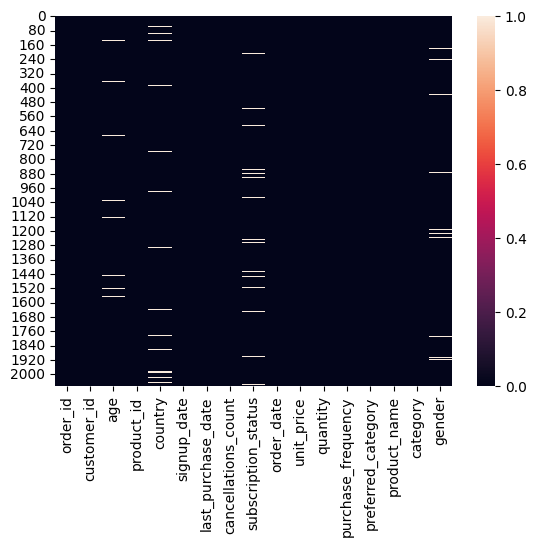

In [61]:
sns.heatmap(churn.isnull())

#3. Validasi dan Pembersihan Data (J.62DMI00.006.1)

##3.1 Membuat Salinan Dataset

In [62]:
churn_clean = churn.copy()

##3.2 Pemeriksaan Tipe Data
Pemeriksaan tipe data atribut numerik
Pemeriksaan tipe data atribut kategorikal
Pemeriksaan tipe data atribut tanggal

In [63]:
numerik = churn_clean.select_dtypes(include=['int64', 'float64'])

print("Atribut Numerik:")
print(numerik.columns.tolist())

Atribut Numerik:
['age', 'cancellations_count', 'quantity', 'purchase_frequency']


In [64]:
kategorikal = churn_clean.select_dtypes(include=['object', 'category'])

print("Atribut Kategorikal:")
print(kategorikal.columns.tolist())

Atribut Kategorikal:
['order_id', 'customer_id', 'product_id', 'country', 'signup_date', 'last_purchase_date', 'subscription_status', 'order_date', 'unit_price', 'preferred_category', 'product_name', 'category', 'gender']


In [65]:
tanggal = churn_clean.select_dtypes(include=['datetime64'])

print("Atribut Tanggal:")
print(tanggal.columns.tolist())

Atribut Tanggal:
[]


##3.3 Standarisasi Format Tipe Data

##3.3.1 Standarisasi Atribut Tanggal
Contoh:
signup_date
last_purchase_date
order_date

In [66]:
# Contoh kolom tanggal

kolom_tanggal = [
    'signup_date',
    'last_purchase_date',
    'order_date'
]

for kolom in kolom_tanggal:
    if kolom in churn_clean.columns:
        churn_clean[kolom] = pd.to_datetime(
            churn_clean[kolom],
            errors='coerce'
        )

In [67]:
churn_clean[kolom_tanggal].dtypes

,0
signup_date,datetime64[ns]
last_purchase_date,datetime64[ns]
order_date,datetime64[ns]



##3.3.2 Standarisasi Atribut Numerik
Contoh:
Harga
Jumlah Penjualan
Durasi
Pendapatan


In [68]:
print(churn_clean.head())

  order_id customer_id   age product_id   country signup_date  \
0  ORD5000    CUST1000  39.0    PROD200    Canada  2021-01-07   
1  ORD5001    CUST1001  61.0    PROD201       USA  2020-10-19   
2  ORD5002    CUST1002  26.0    PROD202  Pakistan  2023-06-10   
3  ORD5003    CUST1003  54.0    PROD203     India  2023-07-30   
4  ORD5004    CUST1004  50.0    PROD204     India  2020-12-09   

  last_purchase_date  cancellations_count subscription_status order_date  \
0         2023-02-21                    0              active 2024-08-20   
1         2021-12-08                    0              active 2025-07-17   
2         2023-09-04                    3           cancelled 2025-03-12   
3         2024-02-20                    4              paused 2024-09-19   
4         2024-09-14                    0              active 2024-08-08   

  unit_price  quantity  purchase_frequency preferred_category  product_name  \
0      78.21         5                  37             Sports      Footba

In [69]:
churn_clean.dtypes

,0
order_id,object
customer_id,object
age,float64
product_id,object
country,object
signup_date,datetime64[ns]
last_purchase_date,datetime64[ns]
cancellations_count,int64
subscription_status,object
order_date,datetime64[ns]


In [70]:
kolom_integer = [
    'age'
]

for kolom in kolom_integer:
    if kolom in churn_clean.columns:
        churn_clean[kolom] = pd.to_numeric(
            churn_clean[kolom],
            errors='coerce'
        ).astype('Int64')

In [71]:
churn_clean[kolom_integer].dtypes

,0
age,Int64


In [72]:
kolom_float = [
    'unit_price',
]

for kolom in kolom_float:
    if kolom in churn_clean.columns:
        churn_clean[kolom] = pd.to_numeric(
            churn_clean[kolom],
            errors='coerce'
        ).astype('float')

In [73]:
churn_clean[kolom_float].dtypes

,0
unit_price,float64


##3.3.3 Standarisasi Atribut Kategorikal
Conto:

Kategori Produk
Jenis Kelamin
Status Pelanggan

In [74]:
# Contoh kolom kategorikal

kolom_kategorikal = [
    'preferred_category',
]

for kolom in kolom_kategorikal:
    if kolom in churn_clean.columns:
        churn_clean[kolom] = churn_clean[kolom].astype('category')

In [75]:
churn_clean[kolom_kategorikal].dtypes

,0
preferred_category,category


##3.4 Validasi Hasil Standarisasi Tipe Data

In [76]:
churn_clean.dtypes

,0
order_id,object
customer_id,object
age,Int64
product_id,object
country,object
signup_date,datetime64[ns]
last_purchase_date,datetime64[ns]
cancellations_count,int64
subscription_status,object
order_date,datetime64[ns]


##3.5 Penanganan Missing Value

#Dataset Hasil Cleaning yang Digunakan

##Biasanya untuk proyek Data Analyst cukup memilih satu metode terbaik:
| Tipe Data             | Metode Umum |
| --------------------- | ----------- |
| Numerik               | Median(outlier)  |
| Kategorikal           | Modus       |
| Missing sedikit (<5%) | Drop        |
| Missing banyak        | Imputasi    |


In [77]:
churn_clean.isnull().sum()

,0
order_id,0
customer_id,0
age,46
product_id,0
country,96
signup_date,0
last_purchase_date,0
cancellations_count,0
subscription_status,89
order_date,18


In [78]:
missing_percentage = (churn_clean.isnull().sum() / len(churn_clean)) * 100

missing_percentage.sort_values(ascending=False)

,0
country,4.648910
subscription_status,4.309927
gender,3.244552
age,2.227603
unit_price,1.501211
order_date,0.871671
order_id,0.000000
product_id,0.000000
customer_id,0.000000
cancellations_count,0.000000


## 1. Imputasi kolom numerik (unit_price) menggunakan median

In [79]:
churn_clean['unit_price'] = churn_clean['unit_price'].fillna(
    churn_clean['unit_price'].median()
)

# 2. Imputasi kolom kategorikal (gender) menggunakan modus

In [80]:
churn_clean['gender'] = churn_clean['gender'].fillna(
    churn_clean['gender'].mode()[0]
)

# 3. Drop missing value pada kolom lainnya

In [81]:
kolom_drop = [
    'country',
    'subscription_status',
    'age',
    'order_date'
]

churn_clean = churn_clean.dropna(subset=kolom_drop)

In [82]:
print(churn_clean.isnull().sum())

order_id               0
customer_id            0
age                    0
product_id             0
country                0
signup_date            0
last_purchase_date     0
cancellations_count    0
subscription_status    0
order_date             0
unit_price             0
quantity               0
purchase_frequency     0
preferred_category     0
product_name           0
category               0
gender                 0
dtype: int64


<Axes: >

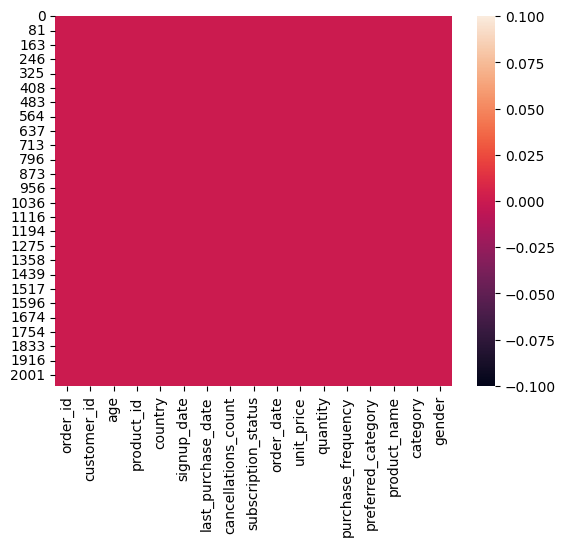

In [89]:
sns.heatmap(churn_clean.isnull())

##3.6 Validasi Hasil Penanganan Missing Value

In [83]:
print("Jumlah data sebelum cleaning :", churn.shape[0])
print("Jumlah data sesudah cleaning :", churn_clean.shape[0])

churn_clean.isnull().sum()

Jumlah data sebelum cleaning : 2065
Jumlah data sesudah cleaning : 1829


,0
order_id,0
customer_id,0
age,0
product_id,0
country,0
signup_date,0
last_purchase_date,0
cancellations_count,0
subscription_status,0
order_date,0


##3.7 Analisis Statistik Setelah Cleaning

In [84]:
churn_clean.describe()

,age,signup_date,last_purchase_date,cancellations_count,order_date,unit_price,quantity,purchase_frequency
count,1829.0,1829,1829,1829.000000,1829,1829.000000,1829.000000,1829.000000
mean,44.352105,2022-02-17 19:53:34.215418368,2023-12-04 20:19:33.100054784,2.434117,2023-11-22 19:56:43.171131648,781.768852,59.606889,25.140514
min,-99.0,2020-08-20 00:00:00,2020-09-20 00:00:00,0.000000,2020-09-28 00:00:00,2.850000,1.000000,1.000000
25%,31.0,2021-05-23 00:00:00,2023-03-03 00:00:00,1.000000,2023-02-17 00:00:00,112.730000,3.000000,12.000000
50%,45.0,2022-02-15 00:00:00,2024-01-20 00:00:00,2.000000,2024-01-08 00:00:00,210.630000,5.000000,25.000000
75%,57.0,2022-11-15 00:00:00,2024-11-14 00:00:00,4.000000,2024-10-19 00:00:00,382.880000,7.000000,38.000000
max,250.0,2023-08-20 00:00:00,2025-08-20 00:00:00,5.000000,2025-08-20 00:00:00,85000.000000,9999.000000,49.000000
std,21.888783,NaN,NaN,1.701671,NaN,6255.836030,737.165250,14.279235


In [87]:
print(churn_clean.describe())

             age                    signup_date  \
count     1829.0                           1829   
mean   44.352105  2022-02-17 19:53:34.215418368   
min        -99.0            2020-08-20 00:00:00   
25%         31.0            2021-05-23 00:00:00   
50%         45.0            2022-02-15 00:00:00   
75%         57.0            2022-11-15 00:00:00   
max        250.0            2023-08-20 00:00:00   
std    21.888783                            NaN   

                  last_purchase_date  cancellations_count  \
count                           1829          1829.000000   
mean   2023-12-04 20:19:33.100054784             2.434117   
min              2020-09-20 00:00:00             0.000000   
25%              2023-03-03 00:00:00             1.000000   
50%              2024-01-20 00:00:00             2.000000   
75%              2024-11-14 00:00:00             4.000000   
max              2025-08-20 00:00:00             5.000000   
std                              NaN             1.7

In [88]:
churn_clean.dtypes

,0
order_id,object
customer_id,object
age,Int64
product_id,object
country,object
signup_date,datetime64[ns]
last_purchase_date,datetime64[ns]
cancellations_count,int64
subscription_status,object
order_date,datetime64[ns]


#4. Penanganan Outlier

##4.1 Identifikasi Outlier pada Atribut Numerik

In [90]:
kolom_numerik = churn_clean.select_dtypes(
    include=['int64', 'float64']
).columns

print("Kolom Numerik:")
print(kolom_numerik.tolist())

Kolom Numerik:
['age', 'cancellations_count', 'unit_price', 'quantity', 'purchase_frequency']


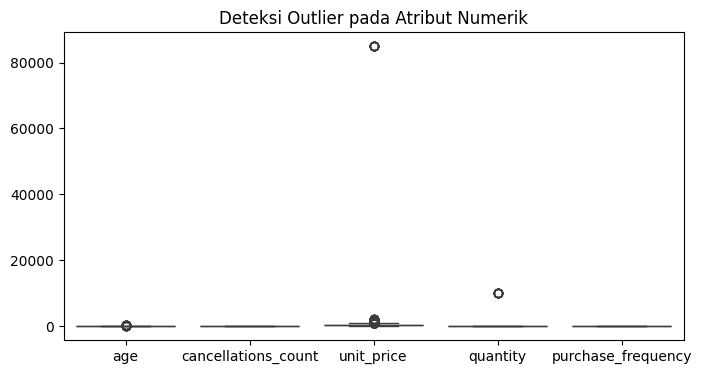

In [92]:
plt.figure(figsize=(8,4))

sns.boxplot(data=churn_clean[kolom_numerik])

plt.title('Deteksi Outlier pada Atribut Numerik')
plt.show()

In [93]:
for kolom in kolom_numerik:

    Q1 = churn_clean[kolom].quantile(0.25)
    Q3 = churn_clean[kolom].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    jumlah_outlier = (
        (churn_clean[kolom] < lower_bound) |
        (churn_clean[kolom] > upper_bound)
    ).sum()

    print(f"{kolom}: {jumlah_outlier} outlier")

age: 15 outlier
cancellations_count: 0 outlier
unit_price: 173 outlier
quantity: 10 outlier
purchase_frequency: 0 outlier


##4.2 Penanganan Outlier

In [94]:
df_outlier = churn_clean.copy()

for kolom in kolom_numerik:

    Q1 = df_outlier[kolom].quantile(0.25)
    Q3 = df_outlier[kolom].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df_outlier = df_outlier[
        (df_outlier[kolom] >= lower_bound) &
        (df_outlier[kolom] <= upper_bound)
    ]

In [95]:
print("Jumlah Data Setelah Cleaning :", len(df_outlier))

Jumlah Data Setelah Cleaning : 1637


##4.3 Validasi Hasil Penanganan Outlier

In [96]:
for kolom in kolom_numerik:

    Q1 = df_outlier[kolom].quantile(0.25)
    Q3 = df_outlier[kolom].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    jumlah_outlier = (
        (df_outlier[kolom] < lower_bound) |
        (df_outlier[kolom] > upper_bound)
    ).sum()

    print(f"{kolom}: {jumlah_outlier} outlier")

age: 0 outlier
cancellations_count: 0 outlier
unit_price: 71 outlier
quantity: 0 outlier
purchase_frequency: 0 outlier


##Visualisasi Setelah Penanganan Outlier

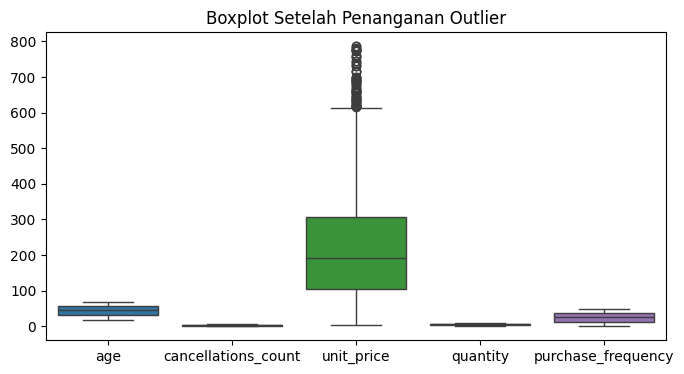

In [97]:
plt.figure(figsize=(8,4))

sns.boxplot(data=df_outlier[kolom_numerik])

plt.title('Boxplot Setelah Penanganan Outlier')
plt.show()

##Membandingkan Dimensi Dataset

In [101]:
print("Sebelum :", churn_clean.shape)
print("Sesudah :", df_outlier.shape)

Sebelum : (1829, 17)
Sesudah : (1637, 17)


#5. Penanganan Data Duplikat

##5.1 Identifikasi Data Duplikat

In [102]:
jumlah_duplikat = df_outlier.duplicated().sum()

print("Jumlah Data Duplikat :", jumlah_duplikat)

Jumlah Data Duplikat : 51


In [103]:
df_outlier[df_outlier.duplicated()]

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
2000,ORD6860,CUST2860,35,PROD2060,Pakistan,2023-02-17,2024-12-17,0,active,2024-09-12,300.08,4,25,Electronics,Conditioner,Beauty,Other
2001,ORD5353,CUST1353,34,PROD553,Germany,2021-03-20,2022-09-09,2,cancelled,2021-04-28,214.73,7,49,Electronics,Tablet,Electronics,Female
2002,ORD6333,CUST2333,55,PROD1533,UK,2020-09-10,2022-12-12,1,active,2021-06-20,690.54,2,34,Sports,Jeans,Clothing,Male
2003,ORD5905,CUST1905,40,PROD1105,USA,2020-09-07,2025-07-12,4,active,2021-01-23,23.66,7,46,Home,Jeans,Clothing,Female
2004,ORD6289,CUST2289,64,PROD1489,Pakistan,2023-03-04,2024-09-26,5,cancelled,2023-10-21,115.36,6,5,Electronics,Camera,Electronics,Female
2007,ORD6731,CUST2731,42,PROD1931,India,2022-08-04,2023-02-03,3,active,2022-10-05,388.38,2,35,Clothing,Dining Table,Home,Female
2008,ORD5065,CUST1065,56,PROD265,Pakistan,2020-11-16,2025-06-12,1,paused,2022-08-15,459.56,3,7,Sports,Smartwatch,Electronics,Female
2009,ORD6323,CUST2323,31,PROD1523,India,2023-05-07,2024-08-15,2,active,2023-11-25,381.19,3,20,Beauty,Running Shoes,Sports,Male
2010,ORD5056,CUST1056,38,PROD256,USA,2023-08-15,2023-12-28,0,active,2025-04-18,472.04,2,17,Electronics,Shirt,Clothing,Male
2012,ORD6118,CUST2118,66,PROD1318,India,2020-09-15,2020-09-20,3,cancelled,2023-08-04,258.37,4,44,Sports,Running Shoes,Sports,Male


##5.2 Penghapusan Data Duplikat

In [104]:
print("Jumlah Data Sebelum :", len(df_outlier))

Jumlah Data Sebelum : 1637


In [105]:
df_final = df_outlier.drop_duplicates()

In [106]:
print("Jumlah Data Setelah :", len(df_final))

Jumlah Data Setelah : 1586


##5.3 Validasi Hasil Penghapusan Duplikat

In [107]:
jumlah_duplikat = df_final.duplicated().sum()

print("Jumlah Data Duplikat :", jumlah_duplikat)

Jumlah Data Duplikat : 0


In [108]:
print("Sebelum :", df_outlier.shape)
print("Sesudah :", df_final.shape)

Sebelum : (1637, 17)
Sesudah : (1586, 17)


#6. Analisis Data (Exploratory Data Analysis)

##6.1 Analisis Korelasi Antar Variabel

In [109]:
numerik = df_final.select_dtypes(include=['int64', 'float64'])

print("Atribut Numerik:")
print(numerik.columns.tolist())

Atribut Numerik:
['age', 'cancellations_count', 'unit_price', 'quantity', 'purchase_frequency']


In [110]:
corr_matrix = numerik.corr()

corr_matrix

,age,cancellations_count,unit_price,quantity,purchase_frequency
age,1.000000,0.018706,-0.042799,0.042181,0.000181
cancellations_count,0.018706,1.000000,-0.005836,0.000751,-0.014418
unit_price,-0.042799,-0.005836,1.000000,-0.575781,-0.002180
quantity,0.042181,0.000751,-0.575781,1.000000,0.010025
purchase_frequency,0.000181,-0.014418,-0.002180,0.010025,1.000000


##6.2 Visualisasi Korelasi

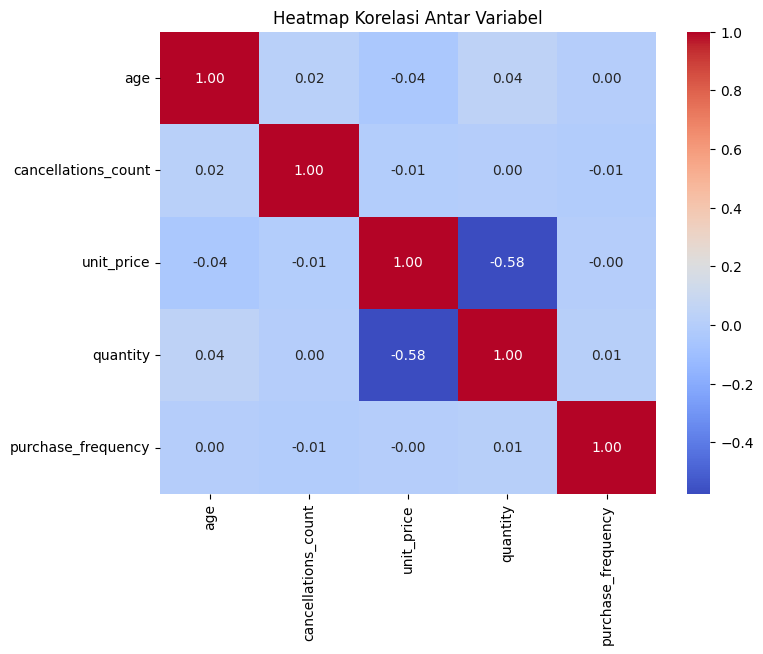

In [111]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

In [112]:
corr_pairs = corr_matrix.unstack()

corr_pairs = corr_pairs[
    corr_pairs.index.get_level_values(0)
    != corr_pairs.index.get_level_values(1)
]

corr_pairs = corr_pairs.abs().sort_values(ascending=False)

corr_pairs.head(10)

,,0
quantity,unit_price,0.575781
unit_price,quantity,0.575781
age,unit_price,0.042799
unit_price,age,0.042799
age,quantity,0.042181
quantity,age,0.042181
cancellations_count,age,0.018706
age,cancellations_count,0.018706
cancellations_count,purchase_frequency,0.014418
purchase_frequency,cancellations_count,0.014418


#7. Penyimpanan Hasil

##7.1 Menyimpan Dataset Bersih

In [113]:
df_final.to_csv(
    'customer_data_clean.csv',
    index=False
)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan


##7.2 Ekspor Dataset Hasil Cleaning

In [114]:
df_export = pd.read_csv(
    'customer_data_clean.csv'
)

df_export.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,ORD5000,CUST1000,39,PROD200,Canada,2021-01-07,2023-02-21,0,active,2024-08-20,78.21,5,37,Sports,Football,Sports,Female
1,ORD5001,CUST1001,61,PROD201,USA,2020-10-19,2021-12-08,0,active,2025-07-17,64.02,8,35,Sports,Refrigerator,Home,Female
2,ORD5002,CUST1002,26,PROD202,Pakistan,2023-06-10,2023-09-04,3,cancelled,2025-03-12,604.14,2,44,Electronics,Hoodie,Clothing,Female
3,ORD5003,CUST1003,54,PROD203,India,2023-07-30,2024-02-20,4,paused,2024-09-19,84.66,4,1,Sports,Conditioner,Beauty,Male
4,ORD5004,CUST1004,50,PROD204,India,2020-12-09,2024-09-14,0,active,2024-08-08,62.66,7,35,Sports,Smartwatch,Electronics,Male
